In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from astropy.coordinates import EarthLocation, AltAz, SkyCoord, ICRS
from astropy.time import Time
import astropy.units as u

In [4]:
df = pd.read_csv('my_data.csv')

In [5]:
df

,Zenith,Azimuth
0,31.113500,143.2640
1,63.157100,27.5691
2,53.190500,30.8202
3,92.738600,341.2320
4,62.365600,63.2526
...,...,...
16280,18.801400,66.5153
16281,87.047600,65.3056
16282,56.088900,93.5034
16283,0.000595,158.3780


In [5]:
deg_to_grad = np.pi / 180
rad_to_deg = 180 / np.pi
print(deg_to_grad, rad_to_deg)

0.017453292519943295 57.29577951308232


In [6]:
df.describe()

,Zenith,Azimuth
count,16285.000000,16285.000000
mean,52.802131,180.577162
std,24.566976,103.551853
min,0.000000,0.070679
25%,35.563000,94.859700
50%,55.059400,174.363000
75%,68.268600,270.504000
max,176.077000,359.995000


In [10]:
#координаты телескопа
lat = 51 + 46/60
lon = 104 + 24/60
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)

In [11]:
#я возьму дату 1 января 2019 года
date = Time('2019-01-01 00:00:00', scale='utc')

In [12]:
zenith = df['Zenith'].values
azimuth = df['Azimuth'].values

In [13]:
rng = np.random.default_rng(seed=42)
ra_list = []
dec_list = []

In [14]:
for i in range(len(zenith)):
    offset_sec = rng.uniform(0, 86400)
    obstime = date + offset_sec * u.s  

    # Высота = 90 - зенитный угол
    alt = 90 - zenith[i]
    az = azimuth[i]

    # Создаём горизонтальные координаты
    altaz = AltAz(alt=alt*u.deg, az=az*u.deg, obstime=obstime, location=location)

    # Преобразуем в RA/Dec
    coord = SkyCoord(altaz).transform_to(ICRS)

   
    ra_list.append(coord.ra.deg)
    dec_list.append(coord.dec.deg)

In [18]:
df['ra'] = ra_list
df['dec'] = dec_list

In [19]:
df.to_csv('radec_output.csv', index=False)

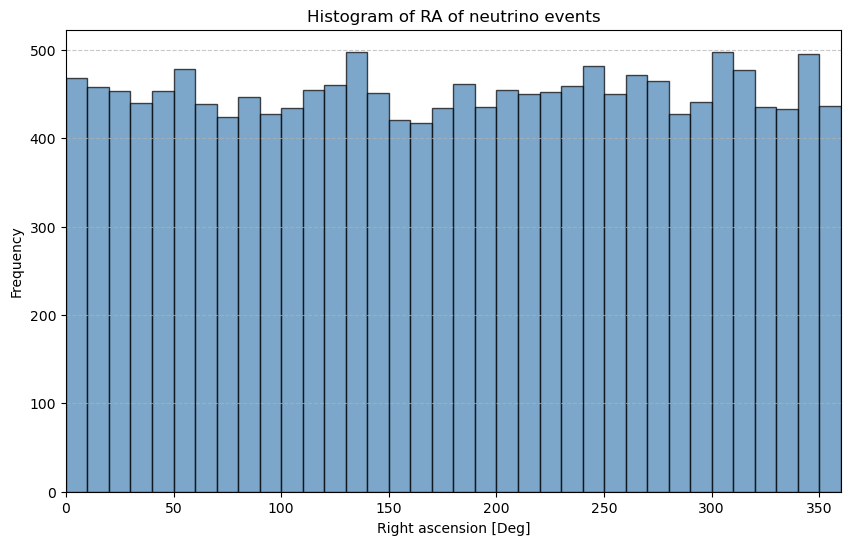

In [20]:
plt.figure(figsize=(10,6))
plt.hist(ra_list, bins=36, range=(0,360), color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Right ascension [Deg]')
plt.ylabel('Frequency')
plt.title('Histogram of RA of neutrino events')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0,360)
plt.show()

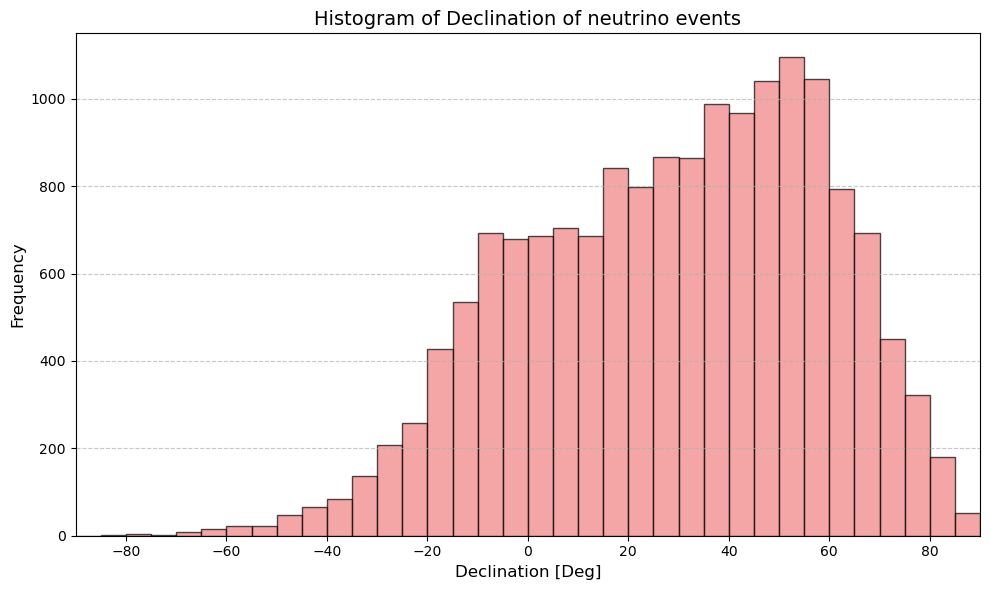

In [22]:
plt.figure(figsize=(10, 6))
counts_dec, bins_dec, patches_dec = plt.hist(dec_list, bins=36, range=(-90, 90),
                                              color='lightcoral', edgecolor='black', alpha=0.7)

plt.xlabel('Declination [Deg]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)  
plt.title('Histogram of Declination of neutrino events', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(-90, 90)

plt.tight_layout()
plt.show()

In [24]:
df.describe()

,Zenith,Azimuth,ra,dec
count,16285.000000,16285.000000,16285.000000,16285.000000
mean,52.802131,180.577162,180.635112,28.796070
std,24.566976,103.551853,104.207189,29.642333
min,0.000000,0.070679,0.001763,-83.257021
25%,35.563000,94.859700,90.248892,6.356511
50%,55.059400,174.363000,181.851531,32.085097
75%,68.268600,270.504000,270.820312,52.566872
max,176.077000,359.995000,359.987021,89.749695


In [25]:
pwd

'C:\\Users\\User\\Desktop'